# HANK Fiscal and Monetary Policy: Baseline

**Implementation author:** André Chadú

## Model summary

This notebook introduces the baseline heterogeneous-agent New Keynesian (HANK) framework used later to study fiscal and monetary policy. Its first computational exercise is a simple heterogeneous-agent (HA) approximation, following the structure of Tomás R. Martinez's course notebook, to calculate and plot intertemporal MPCs.

After running the installation cell, restart the kernel if Jupyter or VS Code indicates that it is necessary.

In [6]:
%pip install numpy scipy matplotlib numba sequence-jacobian


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\andre\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Consumer problem

The computational approximation contains a unit mass of infinitely lived households, one liquid asset $a_{it}$, and inelastic labor. Household $i$ chooses consumption and next-period assets to solve:

$\max_{\{c_{it},a_{it}\}}\; \mathbb{E}_0\sum_{t=0}^{\infty}\beta^t\frac{c_{it}^{1-1/\mathrm{eis}}}{1-1/\mathrm{eis}}$

subject to $c_{it}+a_{it}=(1+r_t)a_{i,t-1}+Z_te_{it}$ and the borrowing constraint $a_{it}\geq\underline{a}$.

There is no aggregate uncertainty, but households differ because $e_{it}$ follows the Markov process constructed by `make_grids`. Aggregate post-tax income is $Z_t$ and individual income is $Z_te_{it}$. This simple block has no labor choice, progressive taxation, or illiquid asset; those features belong to richer HANK extensions.

## Aggregate closure in the simple HA approximation

The code used for the iMPC exercise does not contain a firm, a production function, capital, or wage setting. It treats aggregate output $Y_t$ as demand-driven and uses the fiscal accounting block:

$T_t=(1+r_t)B_{t-1}+G_t-B_t$

with aggregate post-tax income $Z_t=Y_t-T_t$. The market-clearing relationships used in the full fiscal closure are $Y_t=C_t+G_t$ and $A_t=B_t$. For the iMPC plot, we hold $r_t$ fixed and perturb $Z_t$ directly, so this full closure is not solved.

## Scope relative to the richer HANK model

The conceptual HANK baseline can add sticky nominal wages, unions, firms, progressive taxes, and multiple assets. None of those blocks is part of the simple HA computation below.

Accordingly, the iMPC graph must be interpreted as an approximation from a one-asset HA model, not as a replication of the HA-ilíquido line in Auclert, Rognlie, and Straub (2018).

## Calibration for the simple-HA iMPC approximation

We retain the HA-ilíquido table's parameters that map directly into the one-asset household block: $\mathrm{eis}=0.5$, $r=0.05$, $\beta=0.80$, and $\underline a=0$. We normalize steady-state post-tax income to $Z=1$.

The idiosyncratic-income process and numerical grids are inherited from Martinez's notebook: $\rho_e=0.90$, $\mathrm{sd}_e=0.92$, $n_a=200$, and $n_e=10$. Parameters without a counterpart in this block, including the Frisch elasticity, tax curvature, government-spending ratio, and illiquid-asset targets, are intentionally not used.

## Government and fiscal policy

The government issues one-period debt $B_t$, purchases goods $G_t$, and collects tax revenue $T_t$. Its period budget constraint is $B_t=(1+r_{t-1})B_{t-1}+G_t-T_t$. The path for taxes must therefore be consistent with the government's intertemporal budget constraint and the no-Ponzi condition.

Fiscal policy affects equilibrium through government demand, debt issuance, and aggregate post-tax income $Z_t=Y_t-T_t$. In the iMPC exercise, we perturb $Z_t$ directly to isolate the household-consumption channel.

## Monetary authority

In the baseline, the monetary authority follows a real-rate rule with no monetary-policy shock: $r_t=r_{ss}$. Equivalently, a nominal-rate rule offsets expected inflation one-for-one, so the real rate remains at its flexible-price steady-state value.

This passive baseline keeps the interest rate fixed and isolates the fiscal and distributional mechanisms. Later notebooks can replace it with an active rule or introduce shocks to monetary policy.

## Equilibrium and solution map

Given initial nominal wages, government debt, and the household distribution, equilibrium is a path of prices, household allocations, and aggregates that satisfies household optimality, the policy blocks, and market clearing. The goods market condition is $H_t=C_t+G_t-Y_t=0$, while bond-market clearing equates aggregate household asset holdings to government debt.

The diagram below records the dependency structure used in the sequence-space representation. Fiscal inputs and the real interest rate feed into the household block; household consumption and fiscal demand then jointly determine the goods-market residual.

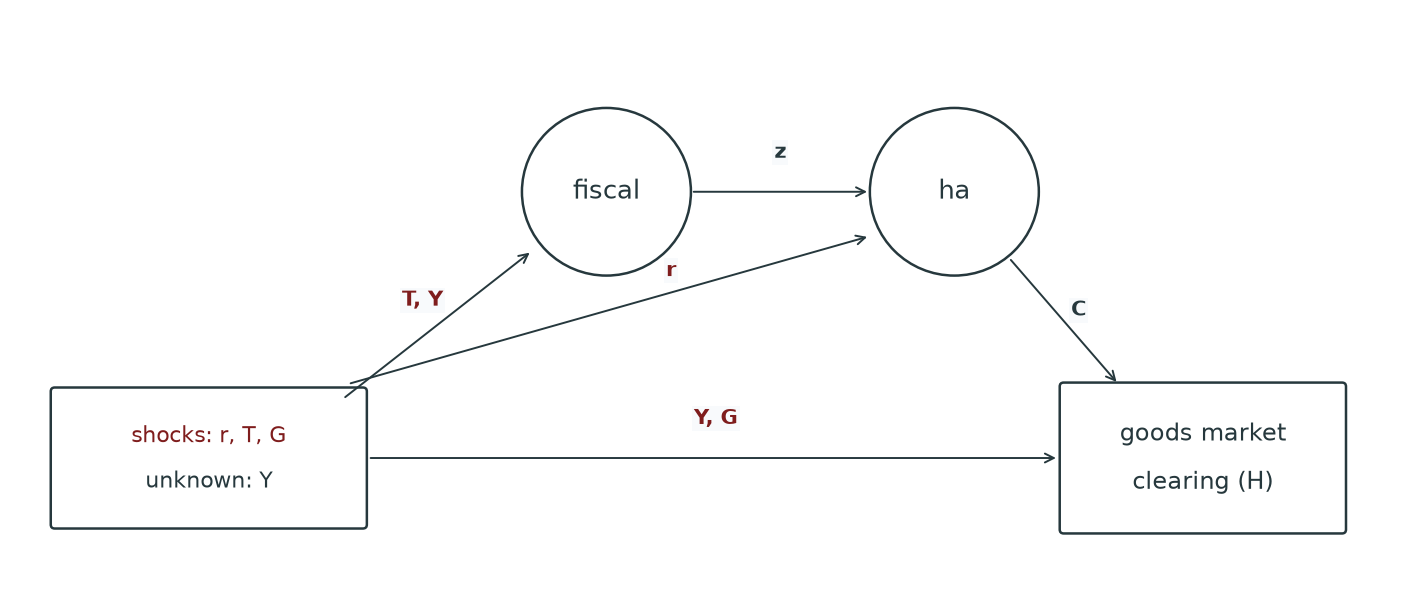

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch, FancyBboxPatch

DARK_RED = '#7F1D1D'
INK = '#26383D'
PANEL = '#F8FAFC'

fig, ax = plt.subplots(figsize=(14, 6), layout='constrained')
ax.set_facecolor(PANEL)

shocks = (2.0, 1.45)
fiscal = (6.0, 4.15)
households = (9.5, 4.15)
goods = (12.0, 1.45)

for center in (fiscal, households):
    ax.add_patch(Circle(center, 0.85, facecolor='white', edgecolor=INK, linewidth=1.8))

def box(center, width, height):
    x, y = center
    ax.add_patch(FancyBboxPatch((x - width / 2, y - height / 2), width, height,
                                boxstyle='round,pad=0.04', facecolor='white',
                                edgecolor=INK, linewidth=1.8))

box(shocks, 3.1, 1.35)
box(goods, 2.8, 1.45)

ax.text(*fiscal, 'fiscal', ha='center', va='center', fontsize=19, color=INK)
ax.text(*households, 'ha', ha='center', va='center', fontsize=19, color=INK)
ax.text(shocks[0], shocks[1] + 0.22, 'shocks: r, T, G', ha='center', va='center', fontsize=16, color=DARK_RED)
ax.text(shocks[0], shocks[1] - 0.24, 'unknown: Y', ha='center', va='center', fontsize=16, color=INK)
ax.text(goods[0], goods[1] + 0.24, 'goods market', ha='center', va='center', fontsize=17, color=INK)
ax.text(goods[0], goods[1] - 0.25, 'clearing (H)', ha='center', va='center', fontsize=17, color=INK)

def arrow(start, end, label, label_xy, label_color=INK):
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle='->', mutation_scale=16,
                                color=INK, linewidth=1.4, shrinkA=2, shrinkB=2))
    ax.text(*label_xy, label, ha='center', va='center', fontsize=15,
            fontweight='bold', color=label_color, bbox={'facecolor': PANEL, 'edgecolor': 'none', 'pad': 1.5})

arrow((3.35, 2.05), (5.25, 3.55), 'T, Y', (4.15, 3.05), DARK_RED)
arrow((3.40, 2.20), (8.65, 3.70), 'r', (6.65, 3.35), DARK_RED)
arrow((6.85, 4.15), (8.65, 4.15), 'z', (7.75, 4.55))
arrow((10.05, 3.48), (11.15, 2.20), 'C', (10.75, 2.95))
arrow((3.60, 1.45), (10.55, 1.45), 'Y, G', (7.10, 1.85), DARK_RED)

ax.set_xlim(0, 14)
ax.set_ylim(0, 6)
ax.set_aspect('auto')
ax.axis('off')
plt.show()


## Intertemporal MPCs

Fiscal policy affects output through government purchases $G_t$, taxes $T_t$, and the household response of consumption. Differentiating the goods-market condition gives the first-order response:

$dY_t=dG_t+\sum_{s=0}^{\infty}\frac{\partial C_t}{\partial Z_s}(dY_s-dT_s)$

The intertemporal marginal propensity to consume (iMPC) measures the response of consumption at date $t$ to a change in household income at date $s$:

$M_{t,s}\equiv\frac{\partial C_t}{\partial Z_s}$

The household intertemporal budget constraint implies that all marginal income is eventually spent. With a constant real interest rate, the iMPCs satisfy $\sum_{t=0}^{\infty}\frac{M_{t,s}}{(1+r)^{t-s}}=1$.

## The Intertemporal Keynesian Cross

Collect the iMPCs $M_{t,s}$ in the matrix $\mathbf{M}_{T\times S}$ and write the time paths as vectors, for example $d\mathbf{Y}\equiv(dY_0,dY_1,\ldots)'$. The linearized equilibrium condition becomes:

$d\mathbf{Y}=d\mathbf{G}-\mathbf{M}d\mathbf{T}+\mathbf{M}d\mathbf{Y}$

This is the intertemporal Keynesian cross: current and future output affect household income, which changes consumption and feeds back into output. If a linear map $\mathcal{M}$ selects a solution satisfying $dY_t\to0$ as $t\to\infty$, then:

$d\mathbf{Y}=\mathcal{M}(d\mathbf{G}-\mathbf{M}d\mathbf{T})$

The baseline will later use this mapping to organize fiscal-policy multipliers and impulse responses.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sequence_jacobian as sj

hh = sj.hetblocks.hh_sim.hh
make_grids = sj.hetblocks.hh_sim.make_grids

def income(Z, e_grid):
    y = Z * e_grid
    return y

hh_simple = hh.add_hetinputs([make_grids, income])

calibration_impc = {
    'eis': 0.5,
    'r': 0.05,
    'beta': 0.80,
    'rho_e': 0.90,
    'sd_e': 0.92,
    'Z': 1.0,
    'min_a': 0.0,
    'max_a': 1_000,
    'n_a': 200,
    'n_e': 10,
}

ss_impc = hh_simple.steady_state(calibration_impc)


In [ ]:
horizon = 6
J_impc = hh_simple.jacobian(ss_impc, inputs=['Z'], T=horizon)
impc_simple_ha = J_impc['C']['Z'][:, 0]

DARK_RED = '#7F1D1D'
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(np.arange(horizon), impc_simple_ha, color=DARK_RED, marker='o', linewidth=2.4,
        label='Simple HA approximation')
ax.axhline(0, color='#6B7280', linewidth=0.9, linestyle='--')
ax.set_xticks(np.arange(horizon))
ax.set_xlabel('Year ($t$)')
ax.set_ylabel('iMPC $M_{t,0}$')
ax.set_title('Intertemporal MPCs: simple HA approximation')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.show()


## Fiscal policy and multipliers

Let a fiscal experiment change government purchases and taxes by the sequences $d\mathbf{G}$ and $d\mathbf{T}$. Two useful summary statistics are the impact multiplier $dY_0/dG_0$ and the present-value cumulative multiplier $\frac{\sum_{t=0}^{\infty}(1+r)^{-t}dY_t}{\sum_{t=0}^{\infty}(1+r)^{-t}dG_t}$.

Under balanced-budget financing, $d\mathbf{G}=d\mathbf{T}$. Substituting this restriction into the intertemporal Keynesian cross, $d\mathbf{Y}=d\mathbf{G}-\mathbf{M}d\mathbf{T}+\mathbf{M}d\mathbf{Y}$, gives the solution $d\mathbf{Y}=d\mathbf{G}$. The fiscal multiplier is therefore one: higher public demand raises output one-for-one, while the increase in household income offsets the tax increase at every date and state.

With deficit financing, $d\mathbf{G}\ne d\mathbf{T}$. The solution can be written as $d\mathbf{Y}=d\mathbf{G}+\mathcal{M}\mathbf{M}(d\mathbf{G}-d\mathbf{T})$. The second term is the endogenous consumption response: its size and timing depend jointly on the iMPC matrix $\mathbf{M}$ and on the path of primary deficits $d\mathbf{G}-d\mathbf{T}$.

For a benchmark experiment, let spending follow $dG_t=\rho_G^t$. Taxes can be chosen to implement a debt path satisfying $dB_t=\rho_B(dB_{t-1}-dG_t)$. When $\rho_B=0$, the budget is balanced period by period; a larger $\rho_B$ makes debt and deficits more persistent. These fiscal paths will be passed to the SSJ model once the fiscal and market-clearing SimpleBlocks are added.

## SSJ fiscal closure for the simple HA model

The next cells close the household block with two SSJ SimpleBlocks: a fiscal block that produces $T_t$, $Z_t$, and the primary deficit, and a market-clearing block that targets $A_t-B_t=0$. To match Martinez's notebook, this fiscal steady state uses $r=0.03$, $G=0.20$, $B=0.80$, $Y=1$, and solves for $\beta$ over $[0.75,0.90]$ to clear the asset market.

For each debt-persistence value $\rho_B$, the experiment uses $dG_t=0.01\rho_G^t$ with $\rho_G=0.8$ and a debt deviation $dB_t=\rho_BdG_0\rho_B^t$. Thus, $\rho_B=0$ is the balanced-budget benchmark, while a larger $\rho_B$ creates a larger and more persistent initial debt-financed component.

In [ ]:
@sj.simple
def fiscal(B, r, G, Y):
    T = (1 + r) * B(-1) + G - B
    Z = Y - T
    deficit = G - T
    return T, Z, deficit

@sj.simple
def mkt_clearing(A, B, Y, C, G):
    asset_mkt = A - B
    goods_mkt = C + G - Y
    return asset_mkt, goods_mkt

ha_fiscal = sj.create_model([hh_simple, fiscal, mkt_clearing], name='Simple HA fiscal model')
calibration_fiscal = {
    'r': 0.03,
    'eis': 0.5,
    'rho_e': 0.90,
    'sd_e': 0.92,
    'G': 0.20,
    'B': 0.80,
    'Y': 1.0,
    'min_a': 0.0,
    'max_a': 1_000,
    'n_a': 200,
    'n_e': 10,
}
ss_fiscal = ha_fiscal.solve_steady_state(
    calibration_fiscal,
    unknowns={'beta': (0.75, 0.90)},
    targets=['asset_mkt'],
)


In [ ]:
T_horizon = 300
rho_G = 0.80
shock_size = 0.01
rho_B_grid = np.linspace(0.0, 0.8, 41)
dG = shock_size * rho_G ** np.arange(T_horizon)
discount = (1 + ss_fiscal['r']) ** (-np.arange(T_horizon))

impact_multiplier = []
cumulative_multiplier = []

for rho_B in rho_B_grid:
    dB = rho_B * dG[0] * rho_B ** np.arange(T_horizon)
    irf = ha_fiscal.solve_impulse_linear(
        ss_fiscal,
        ['Y'],
        ['asset_mkt'],
        {'G': dG, 'B': dB},
    )
    dY = irf['Y']
    impact_multiplier.append(dY[0] / dG[0])
    cumulative_multiplier.append(np.sum(discount * dY) / np.sum(discount * dG))

DARK_RED = '#7F1D1D'
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)

axes[0].plot(rho_B_grid, impact_multiplier, color=DARK_RED, linewidth=2.5)
axes[0].axhline(1, color='#6B7280', linestyle='--', linewidth=1)
axes[0].set_title('Impact multiplier')
axes[0].set_ylabel(r'$dY_0 / dG_0$')

axes[1].plot(rho_B_grid, cumulative_multiplier, color=DARK_RED, linewidth=2.5)
axes[1].axhline(1, color='#6B7280', linestyle='--', linewidth=1)
axes[1].set_title('Cumulative multiplier')
axes[1].set_ylabel(r'Present-value cumulative multiplier')

for ax in axes:
    ax.set_xlabel(r'Debt persistence $\rho_B$')
    ax.set_xlim(rho_B_grid.min(), rho_B_grid.max())
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Fiscal multipliers: simple HA model', y=1.02)
plt.tight_layout()
plt.show()


## Fiscal-policy paths in the simple HA model

The figure below extends the multiplier exercise by plotting the transition paths for four values of debt persistence, $\rho_B\in\{0.3,0.5,0.7,0.8\}$. It uses the same government-spending shock and debt rule as the multiplier experiment.

Unlike the richer quantitative HANK model, the present approximation has no capital, investment, labor choice, nominal rigidity, inflation, or endogenous interest-rate response. The relevant outcomes are therefore output $Y$, consumption $C$, government spending $G$, taxes $T$, primary deficit $G-T$, and government bonds $B$. Output and consumption are reported as percentage deviations from steady state; fiscal flows and debt are reported as percentages of steady-state output.

In [ ]:
rho_B_values = [0.3, 0.5, 0.7, 0.8]
colors = ['#7F1D1D', '#991B1B', '#B91C1C', '#DC2626']
plot_horizon = 11
time = np.arange(plot_horizon)

irfs_by_rho = {}
for rho_B in rho_B_values:
    dB = rho_B * dG[0] * rho_B ** np.arange(T_horizon)
    irfs_by_rho[rho_B] = ha_fiscal.solve_impulse_linear(
        ss_fiscal,
        ['Y'],
        ['asset_mkt'],
        {'G': dG, 'B': dB},
    )

series = {
    'Output': ('Y', 100 / ss_fiscal['Y'], 'Percent of steady state'),
    'Consumption': ('C', 100 / ss_fiscal['C'], 'Percent of steady state'),
    'Government spending': ('G', 100 / ss_fiscal['Y'], 'Percent of steady-state output'),
    'Taxes': ('T', 100 / ss_fiscal['Y'], 'Percent of steady-state output'),
    'Primary deficit': ('deficit', 100 / ss_fiscal['Y'], 'Percent of steady-state output'),
    'Government bonds': ('B', 100 / ss_fiscal['Y'], 'Percent of steady-state output'),
}

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True)
for ax, (title, (variable, scale, ylabel)) in zip(axes.flat, series.items()):
    for rho_B, color in zip(rho_B_values, colors):
        values = irfs_by_rho[rho_B][variable][:plot_horizon] * scale
        ax.plot(time, values, color=color, linewidth=2.2, label=rf'$\rho_B={rho_B:.1f}$')
    ax.axhline(0, color='#9CA3AF', linewidth=0.8, linestyle='--')
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.spines[['top', 'right']].set_visible(False)

for ax in axes[1, :]:
    ax.set_xlabel('Years')

axes[0, 0].legend(frameon=False, fontsize=9)
fig.suptitle('Fiscal-policy paths: simple HA model', y=1.02)
plt.tight_layout()
plt.show()


## Decomposing the consumption response

In the simple HA model, household income is $Z_t=Y_t-T_t$. Let $\mathbf{M}=J_{C,Z}$ denote the household Jacobian of aggregate consumption with respect to post-tax income. The linearized consumption response can therefore be decomposed as:

$d\mathbf{C}=\mathbf{M}d\mathbf{Z}=\mathbf{M}d\mathbf{Y}-\mathbf{M}d\mathbf{T}$

The first term is the output-income channel: higher equilibrium output raises household income and consumption. The second is the tax channel: higher taxes reduce post-tax income and consumption. The full SSJ impulse response $d\mathbf{C}$ should equal the sum of these two components, up to numerical and finite-horizon approximation error. This decomposition replaces the interest-rate and investment channels that are absent from the current model.

In [ ]:
rho_B_decomposition = 0.8
irf_decomposition = irfs_by_rho[rho_B_decomposition]
J_CZ = hh_simple.jacobian(ss_fiscal, inputs=['Z'], T=T_horizon)['C']['Z']

dC_output_income = J_CZ @ irf_decomposition['Y']
dC_tax = -J_CZ @ irf_decomposition['T']
dC_reconstructed = dC_output_income + dC_tax
dC_total = irf_decomposition['C']
decomposition_error = np.max(np.abs(dC_total - dC_reconstructed))

scale_C = 100 / ss_fiscal['C']
fig, ax = plt.subplots(figsize=(8, 4.75))
ax.plot(time, scale_C * dC_total[:plot_horizon], color='#26383D', linewidth=2.8,
        label='Total consumption response')
ax.plot(time, scale_C * dC_output_income[:plot_horizon], color='#7F1D1D', linewidth=2.3,
        label='Output-income channel')
ax.plot(time, scale_C * dC_tax[:plot_horizon], color='#B91C1C', linewidth=2.3, linestyle='--',
        label='Tax channel')
ax.axhline(0, color='#9CA3AF', linewidth=0.8, linestyle='--')
ax.set_xlabel('Years')
ax.set_ylabel('Percent of steady-state consumption')
ax.set_title(r'Consumption decomposition: $\rho_B=0.8$')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f'Maximum decomposition error: {decomposition_error:.2e}')


## Interpretation of the consumption decomposition

For the debt-persistence experiment with $\rho_B=0.8$, the output-income channel is positive: the fiscal expansion raises equilibrium output and thereby household post-tax income. The tax channel is negative because financing the fiscal path requires higher taxes, which reduce disposable income.

The total consumption response is positive but smaller than the output-income channel alone because households internalize both effects. In the impact period, the positive income effect is partly offset by the negative tax effect; as the spending and debt shocks dissipate, both channels converge to zero.

The reported maximum decomposition error is essentially zero, confirming numerically that $d\mathbf{C}=\mathbf{M}d\mathbf{Y}-\mathbf{M}d\mathbf{T}$ for this linearized simple-HA equilibrium. The result should be interpreted as a fiscal income-versus-tax decomposition, not as a decomposition through interest rates or investment, which are absent from the model.

## Monetary policy and HANK

In a HANK model, monetary policy affects aggregate consumption through households with heterogeneous assets, income risk, and marginal propensities to consume. A richer household budget constraint can be written as $c_{it}+a_{i,t+1}=(1+r_t)a_{it}+(1-\tau_t)w_t\ell_{it}z_{it}+T_t$, where the individual state combines asset positions and idiosyncratic productivity.

A change in the real interest rate has a direct intertemporal-substitution effect. It also has indirect general-equilibrium effects through wages $w_t$, labor supply $\ell_{it}$, output, inflation, and the fiscal adjustment needed to stabilize public debt. The aggregate response depends on the distribution of households, since the MPC and the exposure to interest-rate income vary with liquid wealth and portfolio composition.

This heterogeneity weakens simple representative-agent intuition. Households with little liquid wealth may have high MPCs, while asset-rich households have a different exposure to interest-rate changes. Thus, the timing and composition of income changes matter, and Ricardian equivalence need not hold.

The current notebook still keeps $r_t$ fixed and has no labor choice, inflation, or illiquid asset. The next monetary-policy extension will introduce the required household, nominal, and policy blocks before calculating monetary-policy impulse responses and their direct and indirect decompositions.

> **Methodological note — approximation to KMV (2018).** This section represents the key economic mechanisms of *Monetary Policy According to HANK* in a discrete-time, linearized Sequence-Space Jacobian (SSJ) implementation. It preserves the Taylor-rule shock, the contemporaneous Fisher relation, and the fiscal closure in which government debt and purchases are fixed while transfers adjust.
>
> This is not an exact quantitative replication of the original paper. KMV solve the model in continuous time, with a jump-drift earnings process, endogenous hours, and a transaction cost that generates inaction between assets. Here we use the smooth two-asset block and the converged steady state from the SSJ example. The figures should therefore be interpreted as a **qualitative approximation to the transmission channels**, rather than a numerical reproduction of Figures 3 and 4.

## Monetary HANK household problem in discrete time

The monetary-policy extension will give each household liquid wealth $b_t$, illiquid wealth $a_t$, and idiosyncratic productivity $z_t$. At each date, the household chooses consumption $c_t$, hours $\ell_t$, next-period assets $b_{t+1}$ and $a_{t+1}$, and deposits $d_t$ into the illiquid account:

$\max_{\{c_t,\ell_t,b_{t+1},a_{t+1},d_t\}}\; \mathbb{E}_0\sum_{t=0}^{\infty}\beta^t u(c_t,\ell_t)$

with period utility $u(c_t,\ell_t)=\frac{c_t^{1-\gamma}}{1-\gamma}-\varphi\frac{\ell_t^{1+\nu}}{1+\nu}$. Thus, $1/\gamma$ is the elasticity of intertemporal substitution and $1/\nu$ is the Frisch elasticity of labor supply.

## Monetary HANK budget constraint and portfolio frictions

The continuous-time flow constraints become the following discrete-time transition equations:

$b_{t+1}=(1+r_t^b(b_t))b_t+(1-\tau_t)w_tz_t\ell_t+T_t-d_t+\chi(d_t,a_t)-c_t$

$a_{t+1}=(1+r_t^a)a_t+d_t$

Here, $\chi(d_t,a_t)$ is the net liquidity effect of moving funds into the illiquid account; when it represents a transaction cost, it is negative. The constraints are $b_t\geq-\underline b$ and $a_t\geq0$. Borrowing carries an interest-rate wedge, $r_t^b(b_t)=r_t^b+\mathbf{1}_{\{b_t<0\}}\kappa$. The transaction friction can generate a liquidity premium, with $r_t^a>r_t^b$ in equilibrium.

## Discrete-time earnings process

Following the reference model, log earnings can be written as the sum of persistent and transitory components, $\log z_t=x_{1t}+x_{2t}$. A discrete-time approximation to each continuous-time jump-drift component is:

$x_{j,t+1}=\rho_jx_{jt}+J_{j,t+1}$

where $\rho_j=\exp(-\beta_j\Delta)$ captures mean reversion over a period of length $\Delta$. A jump occurs with probability $p_j=1-\exp(-\lambda_j\Delta)$; conditional on a jump, $J_{j,t+1}$ is drawn from a centered normal distribution with variance $\sigma_j^2$, and otherwise it is zero.

For the first SSJ implementation, this process will be represented by a finite Markov chain with transition matrix $\Pi(z'\mid z)$. We can begin with one discretized earnings state $z$ and later add the two-component structure when calibration and grid construction are introduced.

## Stationary value function

For fixed prices and policy instruments, the stationary household problem is summarized by the Bellman equation:

$V(b,a,z)=\max_{c,\ell,d}\left\{u(c,\ell)+\beta\sum_{z'\in\mathcal{Z}}\Pi(z'\mid z)V(b',a',z')\right\}$

subject to $b'=(1+r^b(b))b+(1-\tau)wz\ell+T-d+\chi(d,a)-c$ and $a'=(1+r^a)a+d$, together with $b'\geq-\underline b$, $a'\geq0$, and $c\geq0$.

The solution delivers policy rules for consumption, labor, deposits, and next-period liquid and illiquid assets. In the SSJ implementation, these policy rules and the transition matrix $\Pi$ determine the law of motion for the cross-sectional distribution.

## Final-good firm

A competitive final-good producer aggregates a continuum of differentiated intermediate goods $y_{jt}$ using a CES technology:

$Y_t=\left(\int_0^1y_{jt}^{\frac{\epsilon-1}{\epsilon}}\,dj\right)^{\frac{\epsilon}{\epsilon-1}}$

Cost minimization implies the demand curve $y_{jt}=\left(\frac{p_{jt}}{P_t}\right)^{-\epsilon}Y_t$ and the price index $P_t=\left(\int_0^1p_{jt}^{1-\epsilon}\,dj\right)^{\frac{1}{1-\epsilon}}$. The elasticity of substitution $\epsilon>1$ determines the desired markup of intermediate producers.

## Intermediate-good firms

Each intermediate firm $j$ produces with capital and labor, $y_{jt}=k_{jt}^{\alpha}n_{jt}^{1-\alpha}$. Conditional on its price and demand, it minimizes real costs, $m_ty_{jt}=\min_{k_{jt},n_{jt}}\left\{r_t^kk_{jt}+w_tn_{jt}\right\}$, subject to its production function. This defines the common real marginal cost $m_t$.

Firms choose their price path taking demand as given and face Rotemberg adjustment costs. With gross inflation $\Pi_t=P_t/P_{t-1}$, their discrete-time objective is:

$\max_{\{p_{j,t+s}\}}\;\mathbb{E}_t\sum_{s=0}^{\infty}Q_{t,t+s}\left[\left(\frac{p_{j,t+s}}{P_{t+s}}-m_{t+s}\right)y_{j,t+s}-\frac{\theta}{2}(\Pi_{j,t+s}-1)^2Y_{t+s}\right]$

Here, $Q_{t,t+s}$ is the stochastic discount factor and $\theta$ governs nominal price rigidity. In a zero-inflation steady state, the optimal relative price is one and the marginal cost is $m^*=\frac{\epsilon-1}{\epsilon}$.

## New Keynesian Phillips curve

Under symmetry, $p_{jt}=P_t$ and $\Pi_{jt}=\Pi_t$. Differentiating the intermediate firm's dynamic pricing problem yields the nonlinear Phillips curve:

$\Pi_t(\Pi_t-1)=\frac{\epsilon}{\theta}(m_t-m^*)+\mathbb{E}_t\left[Q_{t,t+1}\frac{Y_{t+1}}{Y_t}\Pi_{t+1}(\Pi_{t+1}-1)\right]$

Current inflation is therefore tied to the current markup gap $m_t-m^*$ and to the discounted expected cost of adjusting prices in the next period. The price-adjustment cost makes firms smooth inflation over time.

Writing net inflation as $\pi_t=\Pi_t-1$, a first-order approximation around the zero-inflation steady state gives $\pi_t=\beta\mathbb{E}_t\pi_{t+1}+\kappa\widehat m_t$, where $\widehat m_t=m_t-m^*$ and $\kappa=\epsilon/\theta$ under this normalization. This Phillips curve will become a `SimpleBlock` in the SSJ implementation.

## Composition of illiquid wealth

The illiquid account can hold productive capital $k_t$ and equity claims $s_t$ on intermediate firms. If $q_t$ is the equity price, individual illiquid wealth is $a_t=k_t+q_ts_t$. Equity is a claim on future firm profits net of price-adjustment costs.

Within the illiquid account, capital and equity can be reallocated without an additional household transaction cost. No arbitrage therefore equates their returns:

$1+r_t^a=1+r_t^k-\delta=\mathbb{E}_t\left[\frac{q_{t+1}+D_{t+1}}{q_t}\right]$

Here, $r_t^k$ is the rental return on capital, $\delta$ is depreciation, and $D_{t+1}$ is the dividend paid by intermediate firms. The liquidity premium arises between the liquid asset $b_t$ and this illiquid account because shifting resources across the two accounts is costly.

## Government and monetary authority

The monetary authority follows a Taylor rule. In log-linear notation, the nominal policy rate is $i_t=r_t^b+\phi_\pi\pi_t+\varepsilon_t$, where $\phi_\pi>1$ and the monetary shock $\varepsilon_t$ is zero in the steady state. The Fisher relation is $r_t^b=i_t-\mathbb{E}_t\pi_{t+1}$, so monetary policy moves the real return on liquid assets.

Fiscal policy chooses taxes $\tau_t$, transfers $T_t$, government purchases $G_t$, and government debt $B_t^g$. Its discrete-time budget constraint is:

$B_{t+1}^g+G_t+T_t=\tau_t\int w_tz_t\ell_t\,d\mu_t+(1+r_t^b)B_t^g$

The fiscal instrument selected to stabilize debt matters for the distributional and aggregate effects of a monetary shock. These relationships will become SSJ `SimpleBlock`s once the household and firm blocks are implemented.

## Equilibrium and market clearing

Let $\mu_t(b,a,z)$ denote the cross-sectional distribution of households. A sequential equilibrium is a path of household policies, prices, aggregate quantities, and distributions that satisfies household optimization, firm optimality, government policies, distributional consistency, and the following market-clearing conditions:

$B_t^h+B_t^g=0$

$A_t=K_t+q_t$

$N_t=\int z_t\ell_t\,d\mu_t$

$Y_t=C_t+I_t+G_t+\Theta_t+\Xi_t+\kappa\int\max\{-b,0\}\,d\mu_t$

The first condition clears the liquid-asset market; the second clears the illiquid account, with the aggregate quantity of equity normalized to one; the third clears labor. The goods-market condition allocates output among consumption, investment, government purchases, Rotemberg costs $\Theta_t$, portfolio transaction costs $\Xi_t$, and the resource cost of the borrowing wedge.

## Calibration: original HANK paper

For the two-asset HANK model, we use the baseline in Kaplan, Moll, and Violante (2018) as the calibration target. The published model is in continuous time; our SSJ version will use one quarter as the discrete period. Thus, the economic specification and targets below are from the paper, while the transition matrix and numerical grids are a discrete approximation.

| Block | Paper parameter | Quarterly implementation |
|---|---:|---:|
| Preferences | mortality $\zeta=1/180$; EIS $=1$; Frisch $=1$; $\varphi=2.2$ | $\gamma=1$, $\nu=1$, $\zeta=1/180$, $\varphi=2.2$ |
| Discounting and survival | annual discount rate $\rho=5.1\%$ | conditional $\beta=e^{-0.051/4}$ and survival $s=e^{-\zeta}$; the continuation factor is $s\beta$ |
| Earnings, component 1 | $\lambda_1=0.080$, $\beta_{z,1}=0.761$, $\sigma_1=1.74$ | quarterly jump-arrival, mean-reversion, and innovation parameters |
| Earnings, component 2 | $\lambda_2=0.007$, $\beta_{z,2}=0.009$, $\sigma_2=1.53$ | quarterly jump-arrival, mean-reversion, and innovation parameters |
| Firms | $\varepsilon=10$, $\theta=100$, $\alpha=0.33$, annual $\delta=7\%$ | $\delta_q=1-(1-0.07)^{1/4}\approx0.0180$ |
| Fiscal policy | $\tau=0.30$, $T/Y=0.06$ | $B/Y=0.233$; in the baseline IRF, $B$ and $G$ stay at their steady states and $T_t$ adjusts to balance the budget |
| Monetary policy | $\phi_\pi=1.25$, annual $r^b=2\%$ | $r_q^b=(1.02)^{1/4}-1\approx0.0050$ |
| Monetary shock | $\varepsilon_0=-0.25$ percentage points per quarter and $\eta=0.5$ | $\varepsilon_t=e^{-\eta t}\varepsilon_0$, equivalently quarterly persistence $e^{-0.5}\approx0.607$ |
| Borrowing | annual wedge $\kappa=6\%$, annual borrowing rate $8\%$; limit = one quarterly labor income | $r^{\mathrm{borr}}=r^b+\kappa$; normalize the limit by model income |
| Profit allocation | fraction reinvested $\omega=\alpha=0.33$ | residual profits are paid in liquid form, proportional to productivity |

The transaction-cost function is explicitly given by $\chi(d,a)=\chi_0|d|+\chi_1|d/a|^{\chi_2}a$, evaluated with $a$ replaced by $\max(a,\underline a)$ near zero. Its calibrated parameters are $\chi_0=0.0438$, $\chi_1=0.956$, $\chi_2=1.402$, and $\underline a=\$1{,}000$ in the paper's dollar normalization.

The five internal calibration targets are mean illiquid wealth $2.92$, mean liquid wealth $0.26$, the fractions $(b=0,a=0)=0.10$, $(b=0,a>0)=0.20$, and $b<0=0.15$. Wealth means are relative to annual output. The paper calibrates $\rho$, $\kappa$, $\chi_0$, $\chi_1$, and $\chi_2$ jointly to these moments; its reported model moments are illiquid wealth $2.92$, liquid wealth $0.23$, and the three fractions $0.10$, $0.19$, and $0.15$.

The discrete implementation below uses these targets and recalibrates $\beta$ and the smooth adjustment-cost scale on its finite grids so that the liquid-asset and aggregate-wealth market-clearing conditions hold.

## Discrete SSJ implementation: two-asset HANK

This block implements the household sector as an SSJ `HetBlock` with liquid assets $b$, illiquid assets $a$, and idiosyncratic earnings. The remaining equilibrium relationships are SSJ `SimpleBlock`s or `SolvedBlock`s: capital and investment, price setting, equity valuation, the Taylor rule, transfer adjustment, and market clearing.

The original KMV economy is continuous time. We use quarterly periods, the paper's quarterly monetary shock, and a finite-state approximation to its earnings process. The official SSJ two-asset EGM block supplies the efficient two-dimensional household solver; the smooth adjustment-cost scale is recalibrated on the discrete grid.

In [ ]:
from sequence_jacobian import simple, combine, create_model, grids, hetblocks
import sequence_jacobian.examples.two_asset as ssj2

# A quarterly, finite-state approximation to the earnings process.
# The paper's two jump components motivate a persistent, dispersed Markov approximation.
def kmv_make_grids(bmin, bmax, amax, kmax, nB, nA, nK, nZ, rho_z, sigma_z):
    b_grid = grids.agrid(amin=bmin, amax=bmax, n=nB)
    a_grid = grids.agrid(amin=0.0, amax=amax, n=nA)
    k_grid = grids.agrid(amin=0.0, amax=kmax, n=nK)[::-1].copy()
    e_grid, _, Pi = grids.markov_rouwenhorst(rho=rho_z, sigma=sigma_z, N=nZ)
    return b_grid, a_grid, k_grid, e_grid, Pi


def kmv_income(e_grid, tax, w, N, T):
    # The SSJ two-asset household block specifically requires the output name z_grid.
    z_grid = (1.0 - tax) * w * N * e_grid + T
    return z_grid


@simple
def kmv_fiscal_transfer(r, Bg, T_ss, r_ss):
    # Baseline KMV closure: debt and purchases are fixed and transfers absorb interest savings.
    T = T_ss - Bg * (r - r_ss)
    return T


@simple
def kmv_finance(i, p, pi, r, div, liquidity_wedge, pshare):
    rb = r - liquidity_wedge
    ra = pshare(-1) * (div + p) / p(-1) + (1.0 - pshare(-1)) * (1.0 + r) - 1.0
    # KMV's continuous-time Fisher relation is contemporaneous: i_t = r_t + pi_t.
    fisher = 1.0 + i - (1.0 + r) * (1.0 + pi)
    return rb, ra, fisher


@simple
def kmv_market_clearing(p, A, B, Bg, C, I, G, CHI, psip, liquidity_wedge, Y):
    wealth = A + B
    asset_mkt = p + Bg - wealth
    goods_mkt = C + I + G + CHI + liquidity_wedge * B - Y
    return asset_mkt, wealth, goods_mkt


hh_kmv = hetblocks.hh_twoasset.hh.add_hetinputs([kmv_income, kmv_make_grids])
production = combine([ssj2.labor, ssj2.investment])
production_solved = production.solved(
    unknowns={'Q': 1.0, 'K': 10.0}, targets=['inv', 'val'], solver='broyden_custom'
)

kmv_blocks = [
    hh_kmv, production_solved, ssj2.pricing_solved, ssj2.arbitrage_solved,
    ssj2.dividend, ssj2.taylor, kmv_fiscal_transfer, ssj2.share_value,
    kmv_finance, ssj2.wage, ssj2.union, kmv_market_clearing,
]
kmv_hank = create_model(kmv_blocks, name='KMV-style discrete two-asset HANK')

kmv_ss_blocks = [
    hh_kmv, ssj2.partial_ss, ssj2.dividend, ssj2.taylor, kmv_fiscal_transfer,
    ssj2.share_value, kmv_finance, ssj2.union_ss, kmv_market_clearing,
]
kmv_hank_ss = create_model(kmv_ss_blocks, name='KMV-style HANK steady state')
print(kmv_hank)

In [ ]:
# Start from SSJ's converged two-asset steady state.  We keep this level calibration
# and impose the KMV monetary and fiscal conventions in *deviations* below.
ssj_hank_ss, ss_ssj, _, kmv_unknowns, kmv_targets, kmv_exogenous = ssj2.dag()
# SteadyStateDict cannot be merged with a plain dict using |.
ss_kmv = ss_ssj.copy()
ss_kmv.update({
    'T_ss': 0.0,                 # keeps the reference SSJ household distribution unchanged
    'T': 0.0,
    'r_ss': ss_ssj['r'],
    'liquidity_wedge': ss_ssj['omega'],
})

print(f"beta: {ss_kmv['beta']:.5f}")
print(f"chi1 (smooth adjustment-cost scale): {ss_kmv['chi1']:.5f}")
print(f"asset-market residual: {ss_kmv['asset_mkt']:.2e}")
print(f"goods-market residual: {ss_kmv['goods_mkt']:.2e}")
print('KMV deviations: contemporaneous Fisher equation; fixed Bg and G; transfers adjust.')

## Monetary-policy IRFs and consumption channels

We apply the paper's surprise easing, $\varepsilon_t=-0.0025e^{-0.5t}$, which is a −1 percentage-point annualized innovation on impact. The Fisher equation is contemporaneous, and with $B^g$ and $G$ fixed the transfer rule is $dT_t=-B^g dr_t$. The consumption decomposition classifies the liquid-return response as direct and the paths of wages/hours, transfers, and illiquid returns as indirect general-equilibrium channels. The household block remains SSJ's smooth two-asset approximation, so this is a KMV-consistent linear benchmark rather than an exact solution of KMV's fixed-cost problem.

In [ ]:
T_monetary = 80
# The household now receives the endogenous transfer T instead of a time-varying tax rate.
J_hh_kmv = hh_kmv.jacobian(ss_kmv, inputs=['rb', 'ra', 'w', 'N', 'T'], T=T_monetary)
G_kmv = kmv_hank.solve_jacobian(
    ss_kmv, kmv_unknowns, kmv_targets, kmv_exogenous, T=T_monetary, Js={'hh': J_hh_kmv}
)

quarters = np.arange(T_monetary)
d_eps = -0.0025 * np.exp(-0.5 * quarters)
irf = {name: G_kmv[name]['rstar'] @ d_eps for name in ['rb', 'ra', 'pi', 'w', 'N', 'T', 'p', 'Y', 'C', 'I']}
d_i = d_eps + ss_kmv['phi'] * irf['pi']

# Exact first-order accounting of household inputs in this discrete representation.
channel_direct = J_hh_kmv['C']['rb'] @ irf['rb']
channel_wage = J_hh_kmv['C']['w'] @ irf['w'] + J_hh_kmv['C']['N'] @ irf['N']
channel_transfer = J_hh_kmv['C']['T'] @ irf['T']
channel_illiquid = J_hh_kmv['C']['ra'] @ irf['ra']
channel_total = channel_direct + channel_wage + channel_transfer + channel_illiquid
print(f"Maximum channel-accounting error: {np.max(np.abs(irf['C'] - channel_total)):.2e}")

show_T = 20
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(quarters[:show_T], 400 * d_eps[:show_T], color='#c43c39', lw=2.3, label='Taylor innovation')
axes[0].plot(quarters[:show_T], 400 * irf['rb'][:show_T], '--', color='#3e62ad', lw=2.3, label='Liquid return')
axes[0].plot(quarters[:show_T], 400 * irf['pi'][:show_T], '--', color='0.15', lw=2.3, label='Inflation')
axes[0].axhline(0, color='0.55', lw=0.8); axes[0].set_title('Panel A. Monetary shock, liquid return, inflation')
axes[0].set(xlabel='Quarters', ylabel='Deviation (pp annual)'); axes[0].legend(frameon=False); axes[0].grid(alpha=0.25)
for name, style, color in [('Y', '--', '0.15'), ('C', '--', '#3e62ad'), ('I', '-', '#c43c39')]:
    axes[1].plot(quarters[:show_T], 100 * irf[name][:show_T] / ss_kmv[name], style, color=color, lw=2.3, label={'Y':'Output','C':'Consumption','I':'Investment'}[name])
axes[1].axhline(0, color='0.55', lw=0.8); axes[1].set_title('Panel B. Aggregate quantities')
axes[1].set(xlabel='Quarters', ylabel='Deviation (percent)'); axes[1].legend(frameon=False); axes[1].grid(alpha=0.25)
fig.suptitle('Monetary-policy impulse responses: discrete two-asset SSJ HANK', y=1.03)
fig.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(quarters[:show_T], 400 * irf['rb'][:show_T], '--', color='#d62728', lw=2.2, label='Liquid return')
axes[0].plot(quarters[:show_T], 100 * irf['w'][:show_T] / ss_kmv['w'], color='#75c6d9', lw=2.2, label='Real wage')
axes[0].plot(quarters[:show_T], 100 * irf['T'][:show_T] / ss_kmv['Y'], '--', color='#3e62ad', lw=2.2, label='Lump-sum transfers (% of Y)')
axes[0].plot(quarters[:show_T], 400 * irf['ra'][:show_T], ':', color='#a84ca8', lw=2.4, label='Illiquid return')
axes[0].plot(quarters[:show_T], 100 * irf['p'][:show_T] / ss_kmv['p'], color='#4f8b3a', lw=2.2, label='Equity price')
axes[0].axhline(0, color='0.55', lw=0.8); axes[0].set_title('Panel A. Prices and fiscal policy')
axes[0].set(xlabel='Quarters', ylabel='Deviation'); axes[0].legend(frameon=False, fontsize=9); axes[0].grid(alpha=0.25)
for values, label, style, color in [(irf['C'], 'Total response', '-', '0.15'), (channel_direct, 'Direct: liquid return', '--', '#d62728'), (channel_wage, 'Indirect: wage and hours', '-', '#75c6d9'), (channel_transfer, 'Indirect: transfers', '--', '#3e62ad'), (channel_illiquid, 'Indirect: illiquid return', ':', '#a84ca8')]:
    axes[1].plot(quarters[:show_T], 100 * values[:show_T] / ss_kmv['C'], style, color=color, lw=2.3, label=label)
axes[1].axhline(0, color='0.55', lw=0.8); axes[1].set_title('Panel B. Consumption decomposition')
axes[1].set(xlabel='Quarters', ylabel='Deviation (percent)'); axes[1].legend(frameon=False, fontsize=9); axes[1].grid(alpha=0.25)
fig.suptitle('Direct and indirect effects of monetary policy: discrete SSJ HANK', y=1.03)
fig.tight_layout(); plt.show()

## References

- Auclert, A., Rognlie, M., & Straub, L. (2018). *The Intertemporal Keynesian Cross*. NBER Working Paper.
- Kaplan, G., Moll, B., & Violante, G. L. (2018). *Monetary Policy According to HANK*. American Economic Review, 108(3), 697–743.
- Martinez, T. R. *Advanced Macroeconomics — Problem Set 2: HANK fiscal and monetary policy*. Course material and Python code: [https://tomasrm.github.io/teaching/advmacro/PSET2_blank.ipynb](https://tomasrm.github.io/teaching/advmacro/PSET2_blank.ipynb)